# TUGAS AKHIR

* Nama: Joice Ocrisa 
* NRP: 5003221066

## Harga Saham BBCA

In [2]:
import os
import sys
# PROJECT_ROOT = "/kaggle/working/tugas-akhir"  # ganti sesuai nama repo kamu
# sys.path.append(PROJECT_ROOT)

# os.chdir("/kaggle/working/tugas-akhir")
os.getcwd()

'c:\\Users\\User\\Documents\\AA - TA\\tugas-akhir\\analysis'

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import itertools
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models import LSTMModel, FEDformer_Model
from models.tuning_lstm import train_lstm_tuning
from models.tuning_fedformer import train_fedformer_tuning

from utils.embed_decomp_layers import fedformer_decompose 
from utils.data_loader import load_stock_data, prepare_univariate_data
from utils.evaluation import calculate_metrics, plot_predictions, plot_comparison, print_metrics


In [23]:
# Configuration `
BANK_CODE = 'BBCA'  
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = DEVICE
print(f"Using device: {DEVICE}")

Using device: cpu


### Data

In [25]:
# date 
start_date = '2025-06-30'
end_date = '2025-07-12'

# get data
df = load_stock_data(BANK_CODE)
df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]
print(f"\nUkuran data: {df.shape}")
print("Tanggal awal:", start_date)
print("Tanggal akhir:", end_date)
print("\nBerikut adalah 5 baris pertama data:")
df

c:\Users\User\Documents\AA - TA\tugas-akhir\indonesia-bank-stock-dataset\datasets\BBCA\BBCA.csv

Ukuran data: (10, 8)
Tanggal awal: 2025-06-30
Tanggal akhir: 2025-07-12

Berikut adalah 5 baris pertama data:


,Close,Date,High,Kode,Low,Nama,Open,Volume
5194,8675.0,2025-06-30,8825.0,BBCA,8550.0,Bank Central Asia Tbk.,8575.0,185441800.0
5195,8700.0,2025-07-01,8775.0,BBCA,8600.0,Bank Central Asia Tbk.,8750.0,82364500.0
5196,8675.0,2025-07-02,8675.0,BBCA,8575.0,Bank Central Asia Tbk.,8575.0,68545100.0
5197,8600.0,2025-07-03,8750.0,BBCA,8600.0,Bank Central Asia Tbk.,8700.0,50370800.0
5198,8650.0,2025-07-04,8700.0,BBCA,8550.0,Bank Central Asia Tbk.,8650.0,43593300.0
5199,8625.0,2025-07-07,8650.0,BBCA,8550.0,Bank Central Asia Tbk.,8625.0,49936900.0
5200,8500.0,2025-07-08,8600.0,BBCA,8425.0,Bank Central Asia Tbk.,8550.0,215611000.0
5201,8500.0,2025-07-09,8550.0,BBCA,8450.0,Bank Central Asia Tbk.,8500.0,94459300.0
5202,8600.0,2025-07-10,8650.0,BBCA,8500.0,Bank Central Asia Tbk.,8525.0,111769400.0
5203,8625.0,2025-07-11,8675.0,BBCA,8575.0,Bank Central Asia Tbk.,8575.0,135986500.0


In [6]:
# Missing Value 

missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")
df = df.dropna(subset=['Close'])


Missing values:
Close     0
Date      0
High      0
Kode      0
Low       0
Nama      0
Open      0
Volume    0
dtype: int64


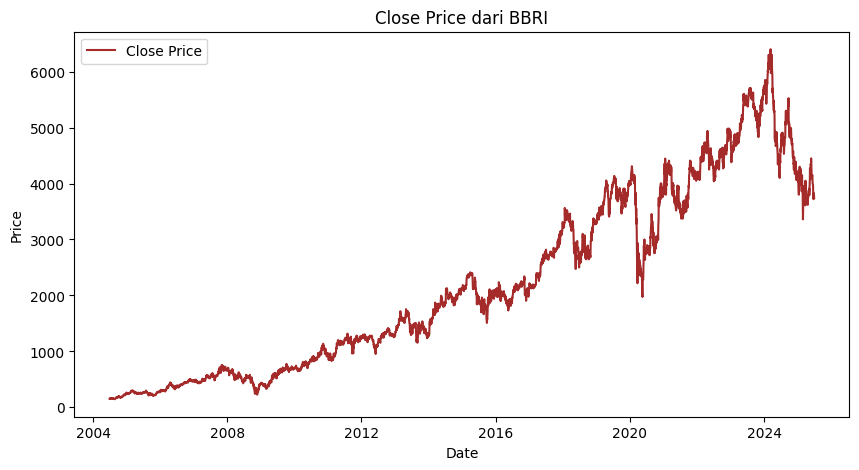

In [7]:
# Time Series Plot

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'brown')
plt.title('Close Price dari ' + BANK_CODE)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [8]:
# Split Data 

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_univariate_data(df, feature_col='Close', seq_len=SEQ_LEN)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3604, 30, 1), y_train shape: (3604, 1)
X_val shape: (772, 30, 1), y_val shape: (772, 1)
X_test shape: (773, 30, 1), y_test shape: (773, 1)


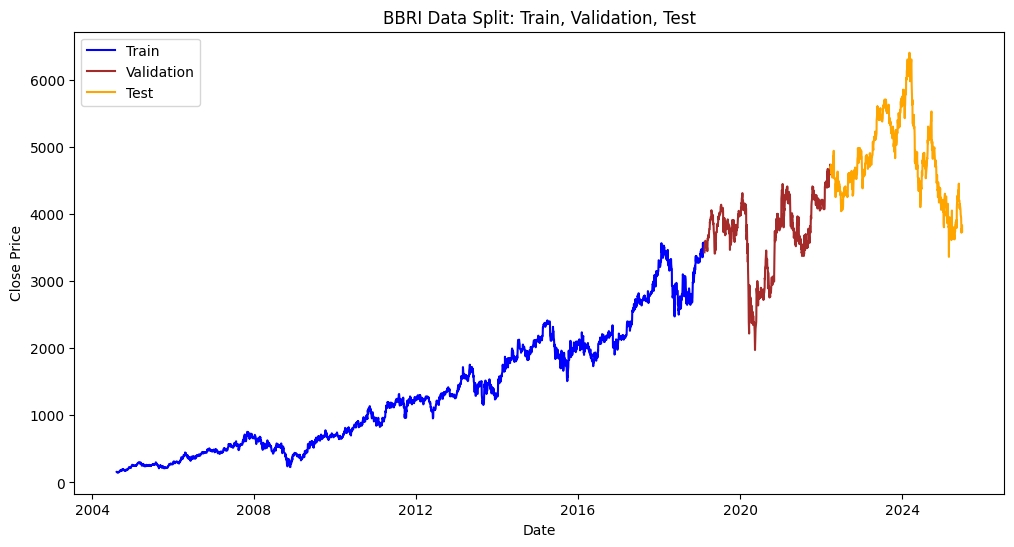

In [9]:
# Plot after split data
Train_size = len(X_train)
Val_size = len(X_val)
Test_size = len(X_test)

Date = df['Date'].values

# Define date for train val and test
idx_train_start = SEQ_LEN - 1
idx_train_end = idx_train_start + Train_size
idx_val_start = idx_train_end 
idx_val_end = idx_val_start + Val_size
idx_test_start = idx_val_end
idx_test_end = idx_test_start + Test_size

train_dates = Date[idx_train_start:idx_train_end]
val_dates = Date[idx_val_start:idx_val_end]
test_dates = Date[idx_test_start:idx_test_end]

# Ensure dates and target lengths match
target_train = y_train[:,0] if y_train.ndim > 1 else y_train
target_val = y_val[:,0] if y_val.ndim > 1 else y_val
target_test = y_test[:,0] if y_test.ndim > 1 else y_test

# Ensure target 1D for plotting
train_inv = scaler.inverse_transform(target_train.reshape(-1, 1)).flatten()
val_inv = scaler.inverse_transform(target_val.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(target_test.reshape(-1, 1)).flatten()

# To avoid if there is a mismatch shape
train_n = min(len(train_dates), len(train_inv))
val_n = min(len(val_dates), len(val_inv))
test_n = min(len(test_dates), len(test_inv))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_dates[:train_n], train_inv[:train_n], label='Train', color='blue')
plt.plot(val_dates[:val_n], val_inv[:val_n], label='Validation', color='brown')
plt.plot(test_dates[:test_n], test_inv[:test_n], label='Test', color='orange')

plt.title(BANK_CODE + ' Data Split: Train, Validation, Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [10]:
# Buat data yang sesuai dengan Data Loader
class stockdataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = stockdataset(X_train, y_train)
val_dataset = stockdataset(X_val, y_val)    
test_dataset = stockdataset(X_test, y_test)

# Gunakan DataLoader untuk batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)    

## **LSTM Model**

### Train-Validation LSTM 

In [26]:
# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size= 64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=0.2
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch).to(DEVICE)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            outputs = lstm_model(X_batch).to(DEVICE)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.009541 | Val Loss: 0.004116
Epoch [2/100] | Train Loss: 0.000237 | Val Loss: 0.001022
Epoch [3/100] | Train Loss: 0.000181 | Val Loss: 0.001050
Epoch [4/100] | Train Loss: 0.000178 | Val Loss: 0.000916
Epoch [5/100] | Train Loss: 0.000166 | Val Loss: 0.001013
Epoch [6/100] | Train Loss: 0.000172 | Val Loss: 0.000891
Epoch [7/100] | Train Loss: 0.000174 | Val Loss: 0.001182
Epoch [8/100] | Train Loss: 0.000183 | Val Loss: 0.000864
Epoch [9/100] | Train Loss: 0.000146 | Val Loss: 0.000828
Epoch [10/100] | Train Loss: 0.000149 | Val Loss: 0.000810
Epoch [11/100] | Train Loss: 0.000145 | Val Loss: 0.000733
Epoch [12/100] | Train Loss: 0.000177 | Val Loss: 0.000690
Epoch [13/100] | Train Loss: 0.000141 | Val Loss: 0.000699
Epoch [14/100] | Train Loss: 0.000130 | Val Loss: 0.000638
Epoch [15/100] | Train Loss: 0.000138 | Val Loss: 0.000753
Epoch [16/100] | Train Loss: 0.000148 | Val Loss: 0.000789
Epoch [17/100] | Train Loss: 0.000130 | Val Loss: 0.000755
Epoch 

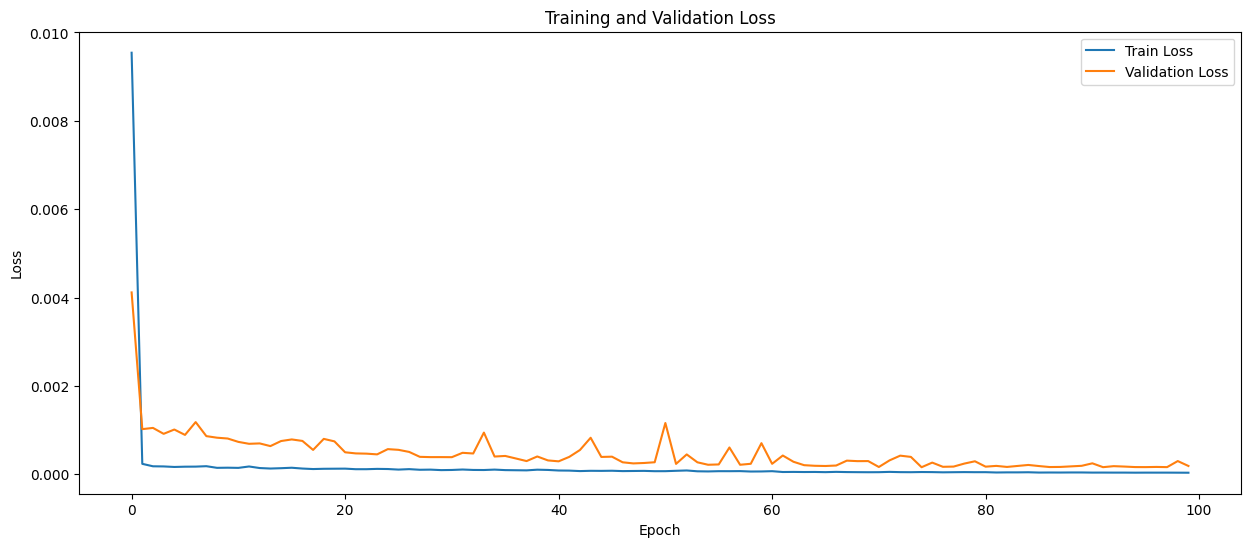

In [27]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Tuning Hyperparameter LSTM

In [60]:
# List Hyperparameter
dropout_list = [0.1, 0.2]
lr_list = [1e-3, 5e-4, 1e-4]
batch_size_list = [32, 64, 128]

In [61]:
import itertools

results = []

for dropout, lr, batch_size in itertools.product(
        dropout_list, lr_list, batch_size_list):

    val_loss = train_lstm_tuning(
        dropout,
        lr,
        batch_size,
        train_dataset,
        val_dataset,
        DEVICE
    )

    results.append({
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch_size,
        'val_loss': val_loss
    })

    print(
        f"Dropout={dropout}, "
        f"LR={lr}, "
        f"Batch={batch_size}, "
        f"Val Loss={val_loss:.6f}"
    )

# ===== BEST CONFIG =====
best_config = min(results, key=lambda x: x['val_loss'])

print("\nBest Hyperparameter Configuration:")
print(best_config)

Dropout=0.1, LR=0.001, Batch=32, Val Loss=0.000218
Dropout=0.1, LR=0.001, Batch=64, Val Loss=0.000550
Dropout=0.1, LR=0.001, Batch=128, Val Loss=0.001558
Dropout=0.1, LR=0.0005, Batch=32, Val Loss=0.000465
Dropout=0.1, LR=0.0005, Batch=64, Val Loss=0.000475
Dropout=0.1, LR=0.0005, Batch=128, Val Loss=0.003457
Dropout=0.1, LR=0.0001, Batch=32, Val Loss=0.000752
Dropout=0.1, LR=0.0001, Batch=64, Val Loss=0.000748
Dropout=0.1, LR=0.0001, Batch=128, Val Loss=0.071986
Dropout=0.2, LR=0.001, Batch=32, Val Loss=0.000192
Dropout=0.2, LR=0.001, Batch=64, Val Loss=0.000699
Dropout=0.2, LR=0.001, Batch=128, Val Loss=0.000308
Dropout=0.2, LR=0.0005, Batch=32, Val Loss=0.000792
Dropout=0.2, LR=0.0005, Batch=64, Val Loss=0.000619
Dropout=0.2, LR=0.0005, Batch=128, Val Loss=0.000521
Dropout=0.2, LR=0.0001, Batch=32, Val Loss=0.000632
Dropout=0.2, LR=0.0001, Batch=64, Val Loss=0.002896
Dropout=0.2, LR=0.0001, Batch=128, Val Loss=0.002121

Best Hyperparameter Configuration:
{'dropout': 0.2, 'learning_r

### Training Validation with Best Hyperparameter

In [63]:
SEQ_LEN = 30  
PRED_LEN = 1  
EPOCHS = 100 
BATCH_SIZE = best_config['batch_size']
LEARNING_RATE = best_config['learning_rate']
dropout = best_config['dropout']

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  

In [68]:
# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=dropout
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch).to(DEVICE)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            outputs = lstm_model(X_batch).to(DEVICE)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.006372 | Val Loss: 0.000483
Epoch [2/100] | Train Loss: 0.000110 | Val Loss: 0.000534
Epoch [3/100] | Train Loss: 0.000092 | Val Loss: 0.000507
Epoch [4/100] | Train Loss: 0.000091 | Val Loss: 0.000531
Epoch [5/100] | Train Loss: 0.000090 | Val Loss: 0.000506
Epoch [6/100] | Train Loss: 0.000085 | Val Loss: 0.000901
Epoch [7/100] | Train Loss: 0.000075 | Val Loss: 0.000722
Epoch [8/100] | Train Loss: 0.000067 | Val Loss: 0.000620
Epoch [9/100] | Train Loss: 0.000072 | Val Loss: 0.000593
Epoch [10/100] | Train Loss: 0.000064 | Val Loss: 0.000618
Epoch [11/100] | Train Loss: 0.000067 | Val Loss: 0.001001
Epoch [12/100] | Train Loss: 0.000067 | Val Loss: 0.000561
Epoch [13/100] | Train Loss: 0.000065 | Val Loss: 0.000676
Epoch [14/100] | Train Loss: 0.000059 | Val Loss: 0.000612
Epoch [15/100] | Train Loss: 0.000058 | Val Loss: 0.000526
Epoch [16/100] | Train Loss: 0.000059 | Val Loss: 0.000710
Epoch [17/100] | Train Loss: 0.000056 | Val Loss: 0.000512
Epoch 

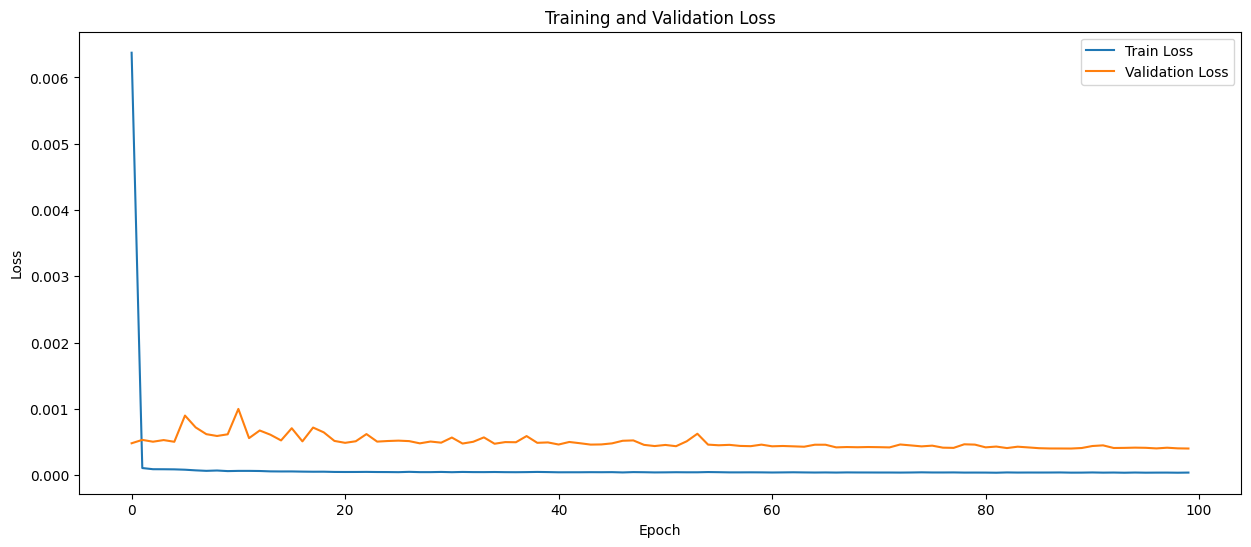

In [69]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Evaluasi Model

In [22]:
# Pengujian Model 
lstm_model.eval()

lstm_predictions = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        lstm_out = lstm_model(X_batch)
        lstm_out = lstm_out.cpu().numpy().flatten()

        lstm_predictions.append(lstm_out)
        y_true_list.append(y_batch.cpu().numpy().flatten())

lstm_pred = np.concatenate(lstm_predictions)
y_true = np.concatenate(y_true_list)

if scaler is not None:
    lstm_pred = scaler.inverse_transform(
        lstm_pred.reshape(-1, 1)
    ).flatten()

    y_true = scaler.inverse_transform(
        y_true.reshape(-1, 1)
    ).flatten()

NameError: name 'lstm_model' is not defined

In [71]:
# Calculate metrics
lstm_metrics = calculate_metrics(y_true, lstm_pred)

print_metrics(lstm_metrics, "LSTM")


LSTM Metrics:
----------------------------------------
MAE       : 304.4140
MSE       : 133086.2812
RMSE      : 364.8099
MAPE      : 3.2836%
R2        : 0.8088
----------------------------------------


## **FEDformer Model**

### Train-Validation FEDformer

In [17]:
class Configs(object):
    ab = 0
    modes = 32
    mode_select = 'random'
    moving_avg = [12, 24]

    seq_len = SEQ_LEN
    label_len = SEQ_LEN // 2
    pred_len = PRED_LEN

    output_attention = False

    enc_in = 1
    dec_in = 1
    c_out = 1

    d_model = 128
    embed_type = 'timeF'
    dropout = 0.1
    freq = 'h'
    factor = 1
    n_heads = 8
    d_ff = 512
    e_layers = 2
    d_layers = 1
    activation = 'gelu'

configs = Configs()
model = FEDformer_Model(configs).to(DEVICE)


fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7]
 fourier enhanced cross attention used!
modes_q=8, index_q=[0, 1, 2, 3, 4, 5, 6, 7]
modes_kv=15, index_kv=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
enc_modes: 15, dec_modes: 8


In [12]:
# Model FEDformer 

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0

    for x_enc, y_true in train_loader:
        x_enc = x_enc.to(DEVICE)
        y_true = y_true.to(DEVICE)

        B, _, C = x_enc.shape
        device = x_enc.device

        x_dec = torch.zeros(
            B,
            configs.label_len + configs.pred_len,
            C,
            device=device
        )

        x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=device)
        x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=device)

        optimizer.zero_grad()

        outputs = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )

        if y_true.dim() == 2:
            y_true = y_true.unsqueeze(-1)

        loss = criterion(outputs, y_true)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)   

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_enc, y_true in val_loader:
            x_enc = x_enc.to(DEVICE)
            y_true = y_true.to(DEVICE)

            B, _, C = x_enc.shape

            x_dec = torch.zeros(
                B,
                configs.label_len + configs.pred_len,
                C,
                device=DEVICE
            )

            x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=DEVICE)
            x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=DEVICE)

            outputs = model(
                x_enc,
                x_mark_enc,
                x_dec,
                x_mark_dec
            )

            if y_true.dim() == 2:
                y_true = y_true.unsqueeze(-1)

            loss = criterion(outputs, y_true)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)       

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # ===================== EARLY STOPPING =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_fedformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load("best_fedformer.pth", map_location=DEVICE))

Epoch [1/100] | Train Loss: 0.028871 | Val Loss: 0.001944
Epoch [2/100] | Train Loss: 0.002999 | Val Loss: 0.001175
Epoch [3/100] | Train Loss: 0.001947 | Val Loss: 0.001188
Epoch [4/100] | Train Loss: 0.000558 | Val Loss: 0.000572
Epoch [5/100] | Train Loss: 0.000345 | Val Loss: 0.000511
Epoch [6/100] | Train Loss: 0.000245 | Val Loss: 0.000523
Epoch [7/100] | Train Loss: 0.000158 | Val Loss: 0.000474
Epoch [8/100] | Train Loss: 0.000154 | Val Loss: 0.000415
Epoch [9/100] | Train Loss: 0.000117 | Val Loss: 0.000378
Epoch [10/100] | Train Loss: 0.000144 | Val Loss: 0.000340
Epoch [11/100] | Train Loss: 0.000101 | Val Loss: 0.000317
Epoch [12/100] | Train Loss: 0.000093 | Val Loss: 0.000283
Epoch [13/100] | Train Loss: 0.000099 | Val Loss: 0.000251
Epoch [14/100] | Train Loss: 0.000068 | Val Loss: 0.000256
Epoch [15/100] | Train Loss: 0.000063 | Val Loss: 0.000234
Epoch [16/100] | Train Loss: 0.000059 | Val Loss: 0.000233
Epoch [17/100] | Train Loss: 0.000065 | Val Loss: 0.000182
Epoch 

<All keys matched successfully>

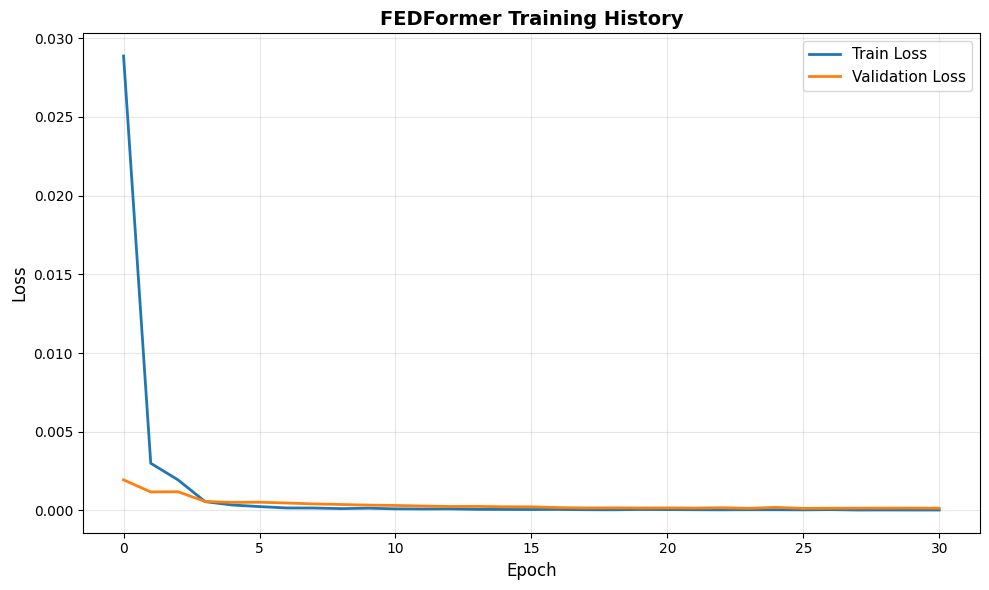

In [16]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('FEDFormer Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Tuning Hyperparameter FEDformer

In [18]:
# List Hyperparameter
dropout_list = [0.1, 0.2]
lr_list = [1e-3, 5e-4, 1e-4]
batch_size_list = [32, 64, 128]

In [ ]:
results_fedformer = []

for dropout, lr, batch_size in itertools.product(
        dropout_list, lr_list, batch_size_list):

    val_loss = train_fedformer_tuning(
        dropout=dropout,
        lr=lr,
        batch_size=batch_size,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        DEVICE=DEVICE,
        base_configs=configs
    )

    # ===== SKIP HASIL RUSAK =====
    if math.isnan(val_loss) or math.isinf(val_loss):
        print(
            f"[SKIP] Dropout={dropout}, "
            f"LR={lr}, "
            f"Batch={batch_size} → invalid loss"
        )
        continue

    results_fedformer.append({
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch_size,
        'val_loss': val_loss
    })

    print(
        f"[FEDformer] Dropout={dropout}, "
        f"LR={lr}, "
        f"Batch={batch_size}, "
        f"Val Loss={val_loss:.6f}"
    )

best_config_fedformer = min(
    results_fedformer, key=lambda x: x['val_loss']
)

print("\nBest FEDformer Hyperparameter Configuration:")
print(best_config_fedformer)

### Training Validation with Best Hyperparameter

In [17]:
BATCH_SIZE = best_config_fedformer['batch_size']
LEARNING_RATE = best_config_fedformer['learning_rate']
dropout = best_config_fedformer['dropout']

# BATCH_SIZE = 32
# LEARNING_RATE = 0.001
# dropout = 0.1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

final_configs = copy.deepcopy(configs)
final_configs.dropout = dropout

model = FEDformer_Model(final_configs).to(DEVICE)


fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7]
 fourier enhanced cross attention used!
modes_q=8, index_q=[0, 1, 2, 3, 4, 5, 6, 7]
modes_kv=15, index_kv=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
enc_modes: 15, dec_modes: 8


In [20]:
# FEDformer model
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0

    for x_enc, y_true in train_loader:
        x_enc = x_enc.to(DEVICE)
        y_true = y_true.to(DEVICE)

        B, _, C = x_enc.shape
        device = x_enc.device

        x_dec = torch.zeros(
            B,
            configs.label_len + configs.pred_len,
            C,
            device=device
        )

        x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=device)
        x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=device)

        optimizer.zero_grad()

        outputs = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )

        if y_true.dim() == 2:
            y_true = y_true.unsqueeze(-1)

        loss = criterion(outputs, y_true)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)   

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_enc, y_true in val_loader:
            x_enc = x_enc.to(DEVICE)
            y_true = y_true.to(DEVICE)

            B, _, C = x_enc.shape

            x_dec = torch.zeros(
                B,
                configs.label_len + configs.pred_len,
                C,
                device=DEVICE
            )

            x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=DEVICE)
            x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=DEVICE)

            outputs = model(
                x_enc,
                x_mark_enc,
                x_dec,
                x_mark_dec
            )

            if y_true.dim() == 2:
                y_true = y_true.unsqueeze(-1)

            loss = criterion(outputs, y_true)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)       

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # ===================== EARLY STOPPING =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_fedformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load("best_fedformer.pth", map_location=DEVICE))

Epoch [1/100] | Train Loss: 0.003214 | Val Loss: 0.000406
Epoch [2/100] | Train Loss: 0.000759 | Val Loss: 0.000803
Epoch [3/100] | Train Loss: 0.000430 | Val Loss: 0.000311
Epoch [4/100] | Train Loss: 0.000183 | Val Loss: 0.000366
Epoch [5/100] | Train Loss: 0.000134 | Val Loss: 0.000224
Epoch [6/100] | Train Loss: 0.000084 | Val Loss: 0.000324
Epoch [7/100] | Train Loss: 0.000078 | Val Loss: 0.000197
Epoch [8/100] | Train Loss: 0.000062 | Val Loss: 0.000216
Epoch [9/100] | Train Loss: 0.000049 | Val Loss: 0.000201
Epoch [10/100] | Train Loss: 0.000047 | Val Loss: 0.000137
Epoch [11/100] | Train Loss: 0.000040 | Val Loss: 0.000133
Epoch [12/100] | Train Loss: 0.000037 | Val Loss: 0.000203
Epoch [13/100] | Train Loss: 0.000036 | Val Loss: 0.000169
Epoch [14/100] | Train Loss: 0.000032 | Val Loss: 0.000127
Epoch [15/100] | Train Loss: 0.000033 | Val Loss: 0.000132
Epoch [16/100] | Train Loss: 0.000039 | Val Loss: 0.000129
Epoch [17/100] | Train Loss: 0.000027 | Val Loss: 0.000130
Epoch 

<All keys matched successfully>

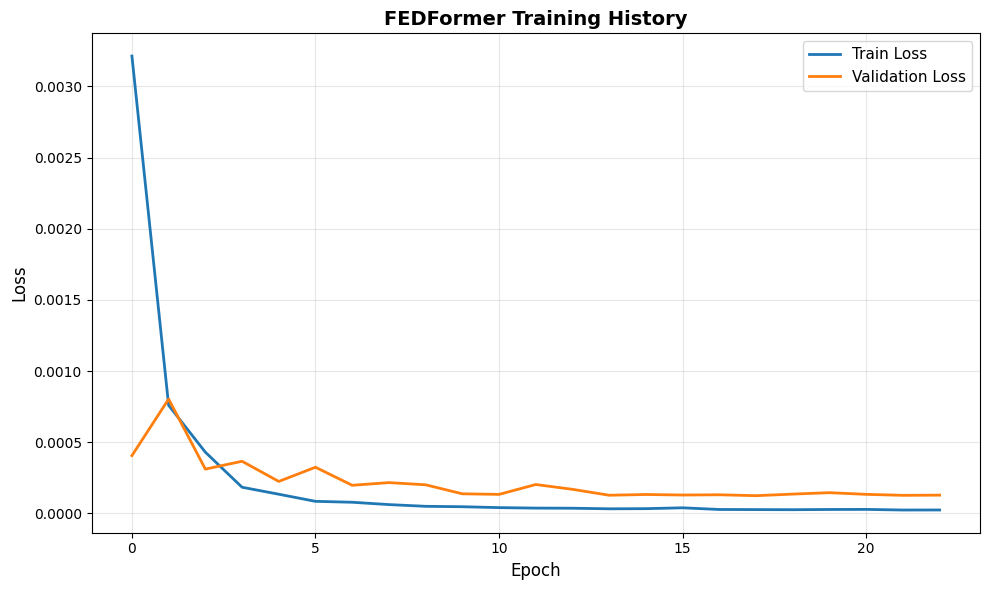

In [21]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('FEDFormer Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Evaluasi Model

In [25]:
model.eval()

fedformer_predictions = []
y_true_fedformer = []

with torch.no_grad():
    for x_enc, y_batch in test_loader:
        x_enc = x_enc.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        B, _, C = x_enc.shape

        # Decoder dummy input
        x_dec = torch.zeros(
            B,
            configs.label_len + configs.pred_len,
            C,
            device=DEVICE
        )
        x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=DEVICE)
        x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=DEVICE)

        outputs = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )  # [B, pred_len, c_out]

        # Pastikan dimensi target
        if y_batch.dim() == 2:
            y_batch = y_batch.unsqueeze(-1)

        # Ambil pred_len terakhir & flatten
        fedformer_predictions.append(
            outputs.cpu().numpy().reshape(-1)
        )
        y_true_fedformer.append(
            y_batch[:, -configs.pred_len:, :].cpu().numpy().reshape(-1)
        )


In [26]:
fedformer_pred = np.concatenate(fedformer_predictions)
y_true_fedformer = np.concatenate(y_true_fedformer)

if scaler is not None:
    fedformer_pred = scaler.inverse_transform(
        fedformer_pred.reshape(-1, 1)
    ).flatten()

    y_true_fedformer = scaler.inverse_transform(
        y_true_fedformer.reshape(-1, 1)
    ).flatten()


In [27]:
# Calculate metrics
fedformer_metrics = calculate_metrics(y_true_fedformer, fedformer_pred)

print_metrics(fedformer_metrics, "FEDformer")


FEDformer Metrics:
----------------------------------------
MAE       : 105.1662
MSE       : 19817.7578
RMSE      : 140.7756
MAPE      : 1.1679%
R2        : 0.9715
----------------------------------------


### Plot Dekomposisi FEDformer

In [11]:
# Data train-val
data_train_val = np.concatenate([train_inv[:train_n], val_inv[:val_n]])
dates_train_val = np.concatenate([train_dates[:train_n], val_dates[:val_n]])


df_train_val = pd.DataFrame({
    "Date": dates_train_val,
    "Close": data_train_val
})

df_train_val.set_index("Date", inplace=True)


In [14]:
data_train_val = df_train_val['Close'].values  # numpy [T]
seasonal, trend = fedformer_decompose(
    data_train_val,
    kernel_sizes=configs.moving_avg,
    DEVICE=DEVICE
)

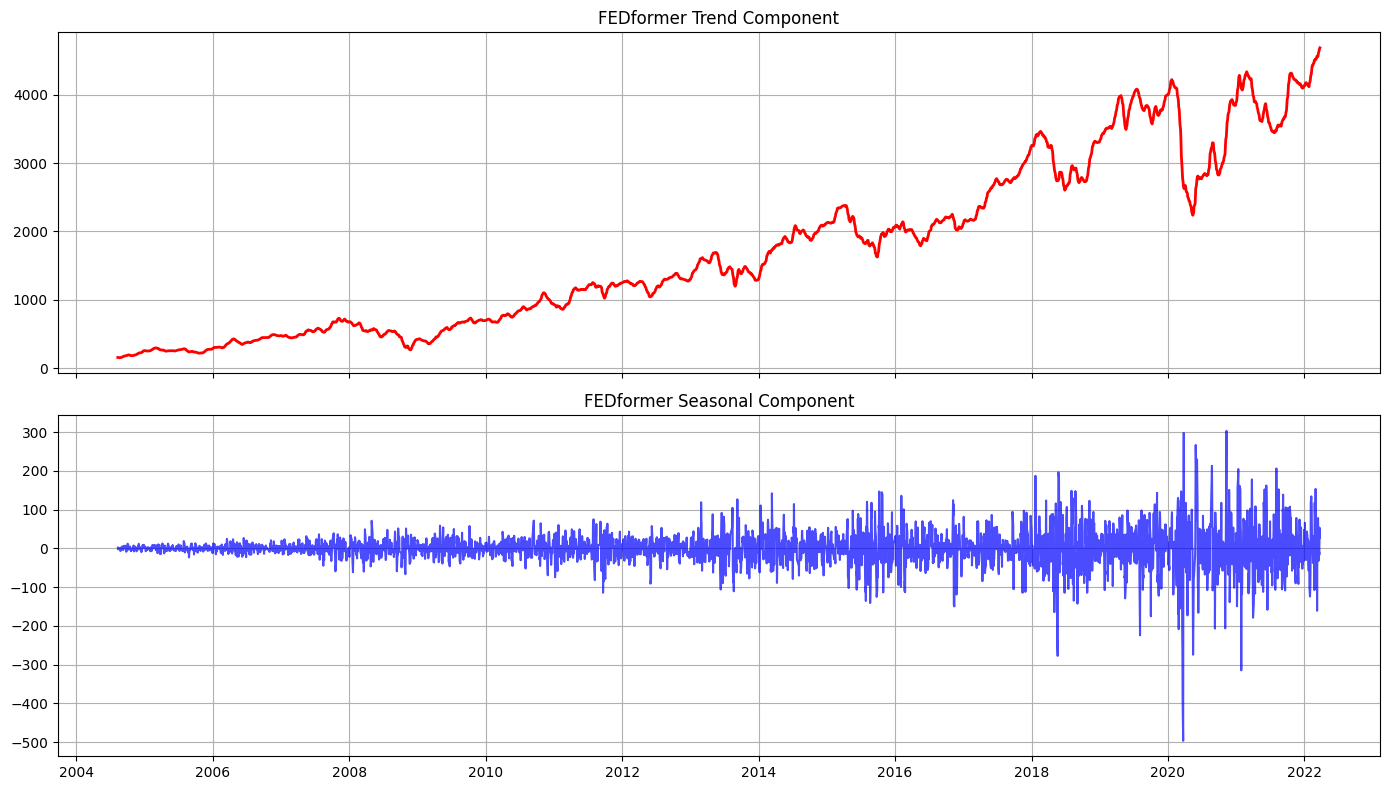

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(df_train_val.index, trend, color='red', linewidth=2)
axs[0].set_title("FEDformer Trend Component")
axs[0].grid(True)

axs[1].plot(df_train_val.index, seasonal, color='blue', alpha=0.7)
axs[1].set_title("FEDformer Seasonal Component")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [16]:
from statsmodels.tsa.seasonal import STL

stl = STL(data_train_val, period=30) # STL untuk mengekstrak komponen musiman dan tren
res = stl.fit()

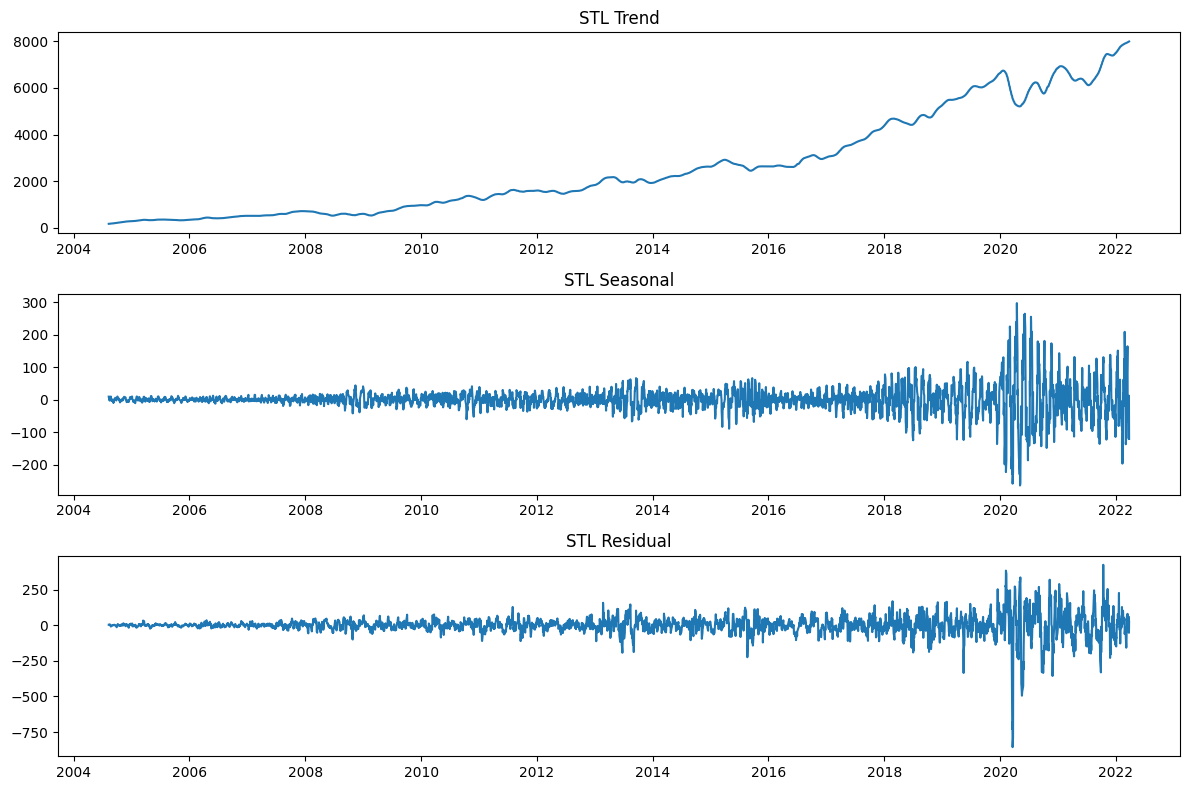

In [ ]:
# plot
plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(df_train_val.index, res.trend)
plt.title("STL Trend")

plt.subplot(3,1,2)
plt.plot(df_train_val.index, res.seasonal)
plt.title("STL Seasonal")

plt.subplot(3,1,3)
plt.plot(df_train_val.index, res.resid)
plt.title("STL Residual")

plt.tight_layout()
plt.show()


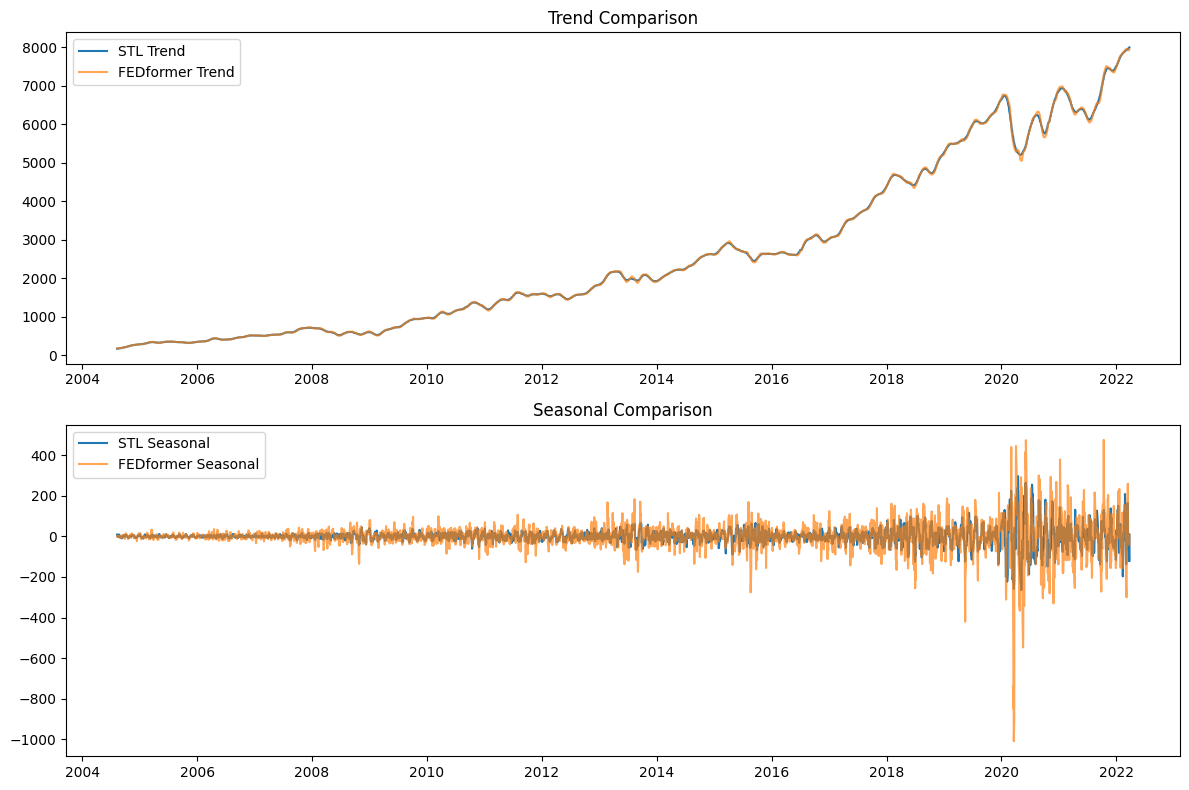

In [49]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(df_train_val.index, res.trend, label="STL Trend")
plt.plot(df_train_val.index, trend, label="FEDformer Trend", alpha=0.7)
plt.legend()
plt.title("Trend Comparison")

plt.subplot(2,1,2)
plt.plot(df_train_val.index, res.seasonal, label="STL Seasonal")
plt.plot(df_train_val.index, seasonal, label="FEDformer Seasonal", alpha=0.7)
plt.legend()
plt.title("Seasonal Comparison")

plt.tight_layout()
plt.show()


### Plot Perbandingan

Plot saved to ../results/BBCA_comparison.png


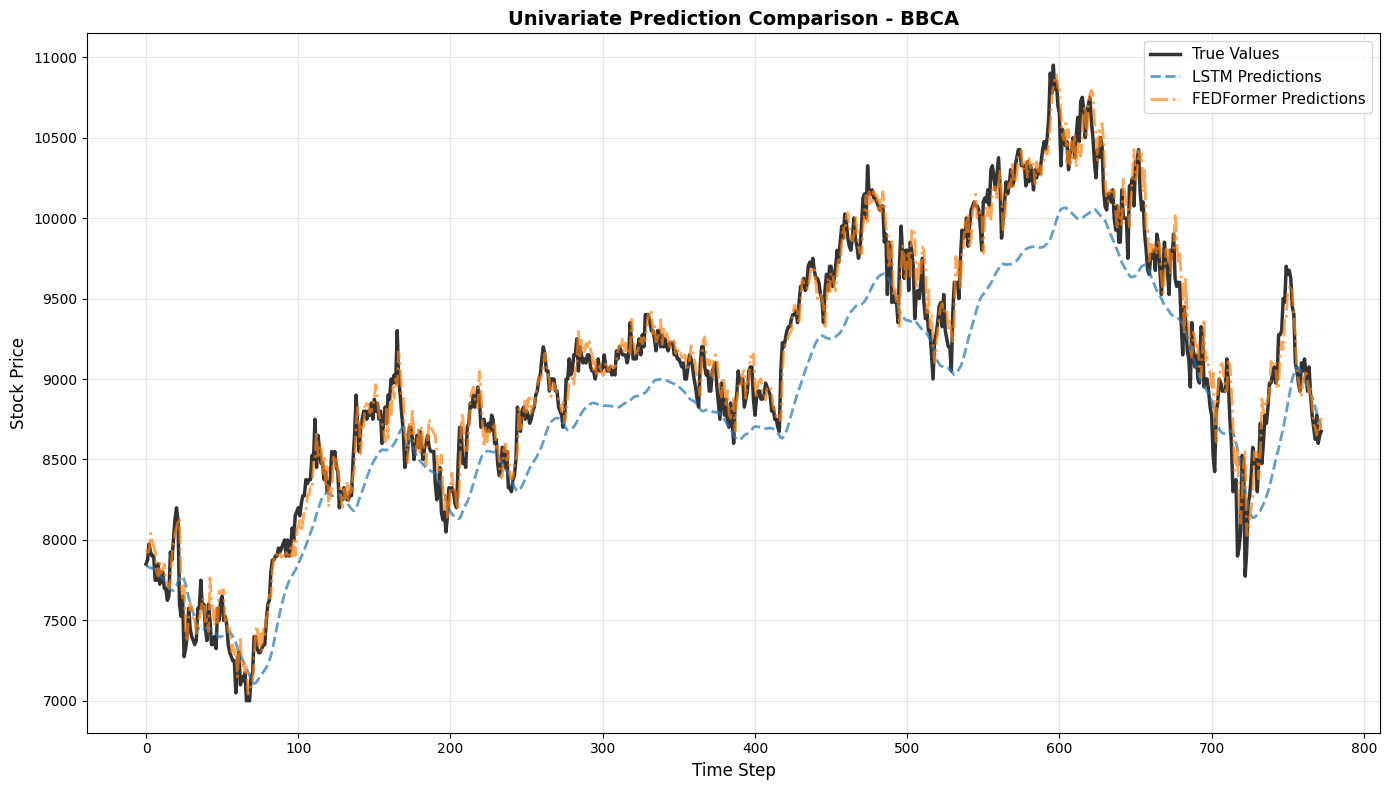

In [72]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x
    
y_true = to_numpy(y_true_fedformer)
lstm_pred = to_numpy(lstm_pred)
fedformer_pred = to_numpy(fedformer_pred)



# Plot comparison
plot_comparison(
    y_true,
    lstm_pred,
    fedformer_pred,
    title=f"Univariate Prediction Comparison - {BANK_CODE}",
    save_path=f"../results/{BANK_CODE}_comparison.png",
    show_plot=True
)


## **Forecasting**

In [39]:
PRED_LEN = 7

In [41]:
history = df[['Close']].values
history_scaled = scaler.transform(history)

x_enc_np = history_scaled[-configs.seq_len:]
x_enc = torch.FloatTensor(x_enc_np).unsqueeze(0).to(DEVICE)

torch.Size([1, 30, 1])


In [44]:
model.eval()
model.to(DEVICE)

predictions = []

for step in range(7):
    # ambil window terakhir
    x_enc_np = history_scaled[-configs.seq_len:]          # [seq_len, 1]
    x_enc = torch.FloatTensor(x_enc_np).unsqueeze(0).to(DEVICE)
    # x_enc: [1, seq_len, 1]

    B, _, C = x_enc.shape

    x_dec = torch.zeros(
        B,
        configs.label_len + configs.pred_len,
        C,
        device=DEVICE
    )

    x_mark_enc = torch.zeros(
        B, configs.seq_len, 4, device=DEVICE
    )

    x_mark_dec = torch.zeros(
        B,
        configs.label_len + configs.pred_len,
        4,
        device=DEVICE
    )

    with torch.no_grad():
        out = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )  # [1, pred_len, 1]

    # ambil 1 step terakhir
    pred_scaled = out[:, -1, :].cpu().numpy()   # [1, 1]
    predictions.append(pred_scaled[0, 0])

    # autoregressive update
    history_scaled = np.vstack([history_scaled, pred_scaled])


In [45]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)

forecast = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)
).flatten()

In [46]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast (Raw)': forecast,
    'Forecast (Rounded)': np.round(forecast)
})

forecast_df

,Date,Forecast (Raw),Forecast (Rounded)
0,2025-07-01,8805.472656,8805.0
1,2025-07-02,8810.131836,8810.0
2,2025-07-03,8876.239258,8876.0
3,2025-07-04,8923.880859,8924.0
4,2025-07-05,9022.810547,9023.0
5,2025-07-06,9025.269531,9025.0
6,2025-07-07,9104.426758,9104.0
